# Flow Toy Example

Using "Back to Basics" with x0-prediction and velocity loss

## Imports, Device Selection, Seed

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch

from backbones.mp_mlp import MPMLP
from diffusion.flow import Flow, FMLoss

In [2]:
if torch.cuda.is_available():
    device = 'cuda:0'
    print('Using gpu')
else:
    device = 'cpu'
    print('Using cpu.')

Using gpu


In [3]:
torch.manual_seed(50192834)

## Toy Data (Circles)

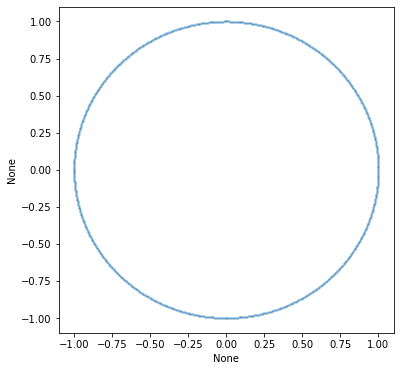

In [4]:
n_points = 1<<10
radii = torch.ones(n_points)
thetas = torch.linspace(-torch.pi, torch.pi, n_points)
x = radii * torch.cos(thetas)
y = radii * torch.sin(thetas)
data = torch.stack([x, y], dim=-1)

# Visualize the data distribution.
plt.figure(figsize=(6, 6))
sns.scatterplot(x=data[:, 0], y=data[:, 1], s=5, alpha=0.5)
plt.show()

In [5]:
# Preprocess to variance 1
dataset = data/data.std()

# split into train and test sets
dataset = dataset[torch.randperm(dataset.shape[0])]
train_data = dataset[:768]
test_data = dataset[768:]

print(train_data.shape, test_data.shape)

torch.Size([768, 2]) torch.Size([256, 2])


## Model, Loss Instantiation

In [6]:
# Model hyperparameters.
in_dim = 2
hidden_dim = 128
num_layers = 3

# Loss hyperparameters.
P_mean = 0.7
P_std = 0.6

# Initialize the model and the loss function.
backbone = MPMLP(in_dim=in_dim, hidden_dim=hidden_dim, num_layers=num_layers).to(device)
flow_model = Flow(label_dim=0, backbone_net=backbone).to(device)
loss_fn = FMLoss(P_mean=P_mean, P_std=P_std)

### Loss time distribution

A popular time sampling distribution on the loss for flow matching is logit-normal. With these parameters, the time distribution looks like this:

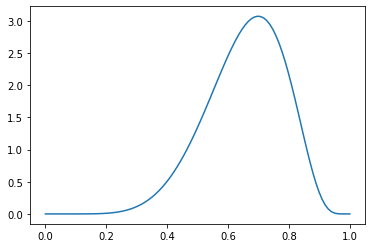

In [7]:
t = torch.linspace(0, 1, 100)

def logit_normal_pdf(t: torch.Tensor, m: float, s: float) -> torch.Tensor:
    """
    Analytical logit-normal density on (0, 1).

    pi(t; m, s) = 1/(s*sqrt(2*pi)) * 1/(t(1-t)) * exp(-(logit(t) - m)^2 / (2*s^2))
    """
    eps = 1e-6
    t = t.clamp(eps, 1.0 - eps)
    logit_t = torch.log(t / (1.0 - t))
    log_coef = -np.log(s) - 0.5 * np.log(2.0 * np.pi)
    log_jac = -torch.log(t * (1.0 - t))
    log_exp = -0.5 * ((logit_t - m) / s) ** 2
    return torch.exp(log_coef + log_jac + log_exp)

plt.plot(t, logit_normal_pdf(t, P_mean, P_std))
plt.show()

## Train

In [8]:
lr = 5e-3
optimizer = torch.optim.Adam(flow_model.parameters(), lr=lr)
n_iters = 1<<10
batch_size = 8<<5

losses=[]

for step in range(n_iters):
    permutation = torch.randperm(dataset.size()[0])
    loss_accum = torch.tensor(0).to(torch.float32)
    for i in range(0, dataset.size()[0], batch_size):
        optimizer.zero_grad()
        indices = permutation[i:i + batch_size]
        batch_x = dataset[indices].to(device)
        loss = loss_fn(flow_model, batch_x)
        loss = loss.mean()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(flow_model.parameters(), 1.0)
        optimizer.step()
        loss_accum += loss.item()
    loss_accum /= dataset.shape[0]//batch_size
    losses.append(loss_accum)

    if step % (n_iters // 8) == 0:
        print(f'Step {step}, Loss: {loss.item():.4f}')

Step 0, Loss: 8.5182
Step 128, Loss: 1.2865
Step 256, Loss: 1.3592
Step 384, Loss: 1.3473
Step 512, Loss: 1.2608
Step 640, Loss: 1.2532
Step 768, Loss: 1.4703
Step 896, Loss: 1.4623


## Sampling

In [9]:
# Visualize data
viz_data = data[::2]

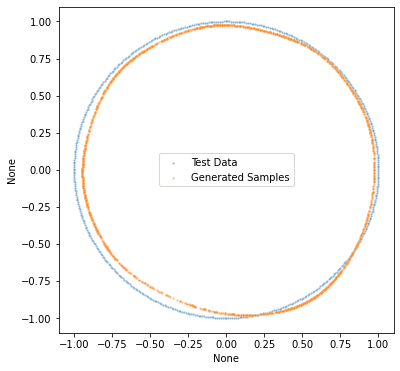

In [10]:
noise = torch.randn([2000, 2]).to(device)
z_t = noise.clone()

num_steps = 100
t_schedule = torch.linspace(0.0, 1.0, num_steps)

flow_model.eval()

with torch.no_grad():
    for i in range(num_steps-1):
        t = t_schedule[i]
        x_pred = flow_model(z_t, t*torch.ones(noise.shape[0], device=device))
        v_pred = (x_pred - z_t) / (1 - t)
        z_t = z_t + (t_schedule[i+1]-t) * v_pred

samples = x_pred.cpu().detach()*data.std()
plt.figure(figsize=(6, 6))
sns.scatterplot(x=viz_data[:, 0], y=viz_data[:, 1], s=5, alpha=0.5, label='Test Data')
sns.scatterplot(x=samples[:, 0].cpu(), y=samples[:, 1].cpu(), s=5, alpha=0.5, label='Generated Samples')
plt.legend()
plt.show()